- 面向过程：把一个需求分解成一系列要执行的步骤，然后按照步骤一次执行这些任务。适用于简单、线性任务
- 面向对象：
    - 对象可理解为现实中的人/物在程序中的数字化身
    - 把一个人/物的特征（属性）和功能（方法）打包到一起，是面向对象的基本单元

### 面向对象编程-类与对象
- 类： 描述一组具有相同属性和方法的**模板**
- 对象：是类的实例，是基于类创建出来的
- 关联：对象由类创建出来的，创建对象的过程也称为**对象的实例化**。一个类可以创建**无数个**对象

### 类定义
- ```__dict__```是Python中用户自定义类实例的一个特殊属性，用于以字典形式存储对象的属性

In [ ]:
# 定义类
class Car:
    pass

# 创建对象，动态添加属性（不推荐这种方式）
c1 = Car()
c1.brand = "BMW"
c1.name = "X5"
c1.price = 500000
print(c1.__dict__)
print(c1)

{'brand': 'BMW', 'name': 'X5', 'price': 500000}


### 定义在类中的函数称为**方法**
- ```__init__```：初始化方法，在对象创建后由解释器**自动调用**，主要用于设置对象的初始状态，设置对象属性
- ```self```：方法的第一个参数，表示**当前创建**的实例对象
- 类中定义实例方法与之前的函数定义方式相同


In [23]:
class Car:
    wheel = 4   # 轮胎数量
    engine = 2  # 引擎数量

    def __init__(self, c_brand: str, c_name: str, c_price: int):
        self.brand = c_brand
        self.name = c_name
        self.price = c_price
        print("Car 类型对象初始化完毕，对象属性已经添加完毕")
    
    def show_info(self):
        print(self.brand, self.name, self.price)
    
    def total_cost(self, discount: float = 1.0, rate: float = 0.1):
        return self.price * discount + self.price * rate

    
    def __str__(self):
        return f"{self.brand} {self.name} {self.price}"
    
    def __eq__(self, other):
        return self.price == other.price and self.brand == other.brand and self.name == other.name
    
    def __lt__(self, other):
        print("__lt__ 被调用")
        return self.price < other.price


# 创建对象，这里会自动调用__init__方法
c1 = Car("Benz", "E300", 800000)

Car 类型对象初始化完毕，对象属性已经添加完毕


In [14]:
print(c1.__dict__)
c1.show_info()
total_cost = c1.total_cost(0.88, 0.1)
print(total_cost)

{'brand': 'Benz', 'name': 'E300', 'price': 800000}
Benz E300 800000
784000.0


- 魔法方法：python中提供的以双下划线开头和结尾的特殊方法，用于定义类的特殊行为
- 魔法方法不需要手动调用，解释器在合适时机自动调用  
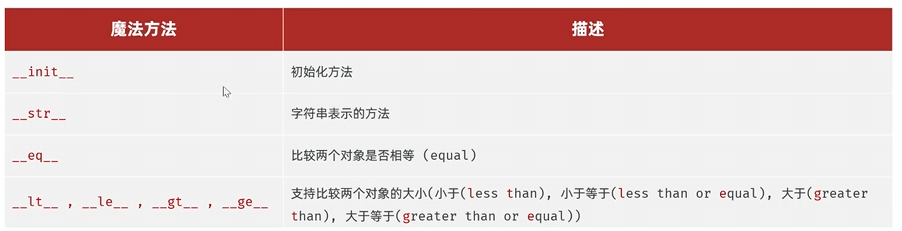  
如果直接比较两个对象```c1 == c2```，那么是比较的两个对象的内存地址。而且默认不能用**>、<**号比较自定义对象

In [12]:
c2 = Car("BMW", "M4", 500000)
print(c2)
print(c1 == c2)

Car 类型对象初始化完毕，对象属性已经添加完毕
False


为什么我只实现了 ```__lt__```，> 却还能用”这个现象? 这是 Python 的一个"退化（fallback）机制"。  
比较```c1>c2```，而类内只有```<```的比较方法，所以内部自动将比较对象互换，相当于比较```c2<c1```，再用```__lt__```方法就行了  
相当于（并不是真的是，只是便于理解）：
```
try:
    c1.__gt__(c2)
except:
    c2.__lt__(c1)
```

In [ ]:
c2 = Car("BMW", "M4", 500000)
print(c2)
print(c1 == c2)
print(c1>c2)

Car 类型对象初始化完毕，对象属性已经添加完毕
BMW M4 500000
False
__lt__ 被调用
True


- 实例属性：每个具体的对象的属性，每个对象都是独立的。比如之前的汽车品牌、价格等，由```self.brand=...```定义的都是实例属性
- 类属性：属于类本身的属性，所有实例共享。如定义的轮胎数量，引擎数量，写在```__init__```外面  
- 值得注意的是，通过实例查找属性时，会**先查找**实例属性，不存在时，**再查找**类属性

In [24]:
c3 = Car("BMW", "M5", 800000)
print(c3.wheel)

Car 类型对象初始化完毕，对象属性已经添加完毕
4
